In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Feature Engineering and Selection/before_feature_real_estate.csv')
df_copy=df.copy()
df.head()

,bhk,price,which_floor,bathrooms,balcony,parking,buildup_area_sqft,is_ready_to_move,furnishing,age_category,location_zone
0,3.0,2.05,Middle,3.0,3.0,1.0,1862.0,1,Semi Furnished,Mid Age,Western Suburbs East
1,1.0,1.33,Lower,2.0,0.0,1.0,790.0,1,Unfurnished,New,Western Suburbs East
2,3.0,7.30,Lower,2.0,0.0,2.0,1430.0,1,Unfurnished,Mid Age,Western Suburbs East
3,3.0,7.60,Higher,4.0,0.0,3.0,2195.0,1,Semi Furnished,Relatively New,Western Suburbs East
4,2.0,3.20,Lower,2.0,1.0,1.0,960.0,1,Unfurnished,Relatively New,South Mumbai


## We adding location col and dropping location zone

In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/Machine Learning/Projects/Real Estate Capstone Project/DataSets/Outliers Removed/Outliers_removed_real_estate.csv')
df2.head()

,bhk,price,age_of_property,which_floor,project_name,bedrooms,bathrooms,balcony,parking,source,location,buildup_area_sqft,carpet_area_sqft,is_ready_to_move,furnishing,price_per_sqft,property_score,locationadvantages,topfacilities,age_category,log_price
0,3.0,2.05,15.0,Middle,Moroccan Cooperative,3.0,3.0,3.0,1.0,kaggle,Goregaon East,1862.0,1425.0,True,Semi Furnished,11009.667025,4,NaN,NaN,Mid Age,1.115142
1,1.0,1.33,1.0,Lower,Rajesh White City,1.0,2.0,0.0,1.0,kaggle,Kandivali East,790.0,479.0,True,Unfurnished,16835.443038,1,NaN,NaN,New,0.845868
2,3.0,7.30,10.0,Lower,Oberoi Esquire,3.0,2.0,0.0,2.0,kaggle,Goregaon East,1430.0,1330.0,True,Unfurnished,51048.951049,3,NaN,NaN,Mid Age,2.116256
3,3.0,7.60,4.0,Higher,Oberoi Esquire,3.0,4.0,0.0,3.0,kaggle,Goregaon East,2195.0,1400.0,True,Semi Furnished,34624.145786,5,NaN,NaN,Relatively New,2.151762
4,2.0,3.20,3.0,Lower,Ajmera Zeon,2.0,2.0,1.0,1.0,kaggle,Wadala East,960.0,860.0,True,Unfurnished,33333.333333,3,NaN,NaN,Relatively New,1.435085


In [ ]:
df['location'] = df2['location']
df.drop('location_zone', axis=1, inplace=True)
df.head()

,bhk,price,which_floor,bathrooms,balcony,parking,buildup_area_sqft,is_ready_to_move,furnishing,age_category,location
0,3.0,2.05,Middle,3.0,3.0,1.0,1862.0,1,Semi Furnished,Mid Age,Goregaon East
1,1.0,1.33,Lower,2.0,0.0,1.0,790.0,1,Unfurnished,New,Kandivali East
2,3.0,7.30,Lower,2.0,0.0,2.0,1430.0,1,Unfurnished,Mid Age,Goregaon East
3,3.0,7.60,Higher,4.0,0.0,3.0,2195.0,1,Semi Furnished,Relatively New,Goregaon East
4,2.0,3.20,Lower,2.0,1.0,1.0,960.0,1,Unfurnished,Relatively New,Wadala East


In [ ]:
df.drop('is_ready_to_move', axis=1, inplace=True)

In [ ]:
# Group locations with fewer than 5 listings into 'Other'
location_counts = df['location'].value_counts()
locations_to_keep = location_counts[location_counts >= 5].index

df['location'] = df['location'].apply(lambda x: x if x in locations_to_keep else 'Other')

print(f"Number of unique locations after grouping: {df['location'].nunique()}")
display(df['location'].value_counts().tail(10))

Number of unique locations after grouping: 98


,count
location,
Gamdevi,6
Mumbai Central,6
Palghar,6
Naigaon West,6
Ramabai Ambedkar Nagar,5
Virar East,5
Churchgate,5
Vile Parle,5
Kamathipura,5


### Next Steps
Now that we have reduced the cardinality of the 'location' column, we can update the feature matrices `X` and `y` and proceed with the model evaluation.

In [ ]:
X = df.drop(columns='price')
y = df['price']

In [ ]:
y_transformed = np.log1p(y)

In [ ]:
X

,bhk,which_floor,bathrooms,balcony,parking,buildup_area_sqft,furnishing,age_category,location
0,3.0,Middle,3.0,3.0,1.0,1862.0,Semi Furnished,Mid Age,Goregaon East
1,1.0,Lower,2.0,0.0,1.0,790.0,Unfurnished,New,Kandivali East
2,3.0,Lower,2.0,0.0,2.0,1430.0,Unfurnished,Mid Age,Goregaon East
3,3.0,Higher,4.0,0.0,3.0,2195.0,Semi Furnished,Relatively New,Goregaon East
4,2.0,Lower,2.0,1.0,1.0,960.0,Unfurnished,Relatively New,Wadala East
...,...,...,...,...,...,...,...,...,...
10031,1.0,Middle,1.0,0.0,1.0,400.0,Unfurnished,Relatively New,Wadala East
10032,2.0,Unknown,2.0,0.0,1.0,753.0,Unknown,Relatively New,Kanjurmarg West
10033,2.0,Middle,2.0,0.0,2.0,851.0,Semi Furnished,Relatively New,Bhandup West
10034,2.0,Unknown,2.0,0.0,0.0,974.0,Unknown,Relatively New,Mira Road East


# Applying All 3 types of Encoding

## Ordinal Encoding

In [ ]:
X.head()

,bhk,which_floor,bathrooms,balcony,parking,buildup_area_sqft,furnishing,age_category,location
0,3.0,Middle,3.0,3.0,1.0,1862.0,Semi Furnished,Mid Age,Goregaon East
1,1.0,Lower,2.0,0.0,1.0,790.0,Unfurnished,New,Kandivali East
2,3.0,Lower,2.0,0.0,2.0,1430.0,Unfurnished,Mid Age,Goregaon East
3,3.0,Higher,4.0,0.0,3.0,2195.0,Semi Furnished,Relatively New,Goregaon East
4,2.0,Lower,2.0,1.0,1.0,960.0,Unfurnished,Relatively New,Wadala East


In [ ]:
columns_to_encode = ['which_floor', 'furnishing', 'age_category', 'location']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import TargetEncoder

### Trying only linear regression

In [ ]:
numerical_features = ['bhk', 'bathrooms', 'balcony', 'parking', 'buildup_area_sqft']
categorical_features = ['which_floor', 'furnishing', 'age_category', 'location']

num_pipeline = Pipeline(steps=[
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

# Updated OrdinalEncoder to handle unknown categories during cross-validation
preprocessor_or = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features),
    ],
    remainder='passthrough'
)

preprocessor_or

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['bhk', 'bathrooms', 'balcony', 'parking',
                                  'buildup_area_sqft']),
                                ('cat',
                                 OrdinalEncoder(handle_unknown='use_encoded_value',
                                                unknown_value=-1),
                                 ['which_floor', 'furnishing', 'age_category',
                                  'location'])])

In [ ]:
pipeline = Pipeline([
    ('preprocessor', preprocessor_or),
    ('regressor', LinearRegression())
])

In [ ]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)
scores = cross_validate(pipeline, X, y_transformed, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

print(f"Average R2 Score: {scores['test_r2'].mean():.4f}")
print(f"Average MAE: {abs(scores['test_neg_mean_absolute_error'].mean()):.4f}")

Average R2 Score: 0.7546
Average MAE: 0.2420


### Trying all the models with Ordinal Encoding

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y_transformed,test_size=0.2,random_state=42)

In [ ]:
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
print(f"Test R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Test MAE: {mean_absolute_error(np.expm1(y_test),np.expm1(y_pred)):.4f}")

Test R2 Score: 0.7571
Test MAE: 1.2884


- Currently making error of 1.28 crore

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

In [ ]:
def scorer(model_name, model):

  output = []

  output.append(model_name)

  pipeline = Pipeline([
      ('preprocessor', preprocessor_or),
      ('regressor', model)
  ])

  kfold = KFold(n_splits=10, shuffle=True, random_state=42)
  scores = cross_validate(pipeline, X, y_transformed, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

  output.append(scores['test_r2'].mean())
  output.append(np.expm1(abs(scores['test_neg_mean_absolute_error'].mean())))

  return output



In [ ]:
model_dict = {
    'linear_reg':LinearRegression(),
    'svr':SVR(),
    'ridge':Ridge(),
    'LASSO':Lasso(),
    'random forest':RandomForestRegressor(),
    'extra trees': ExtraTreesRegressor(),
    'mlp': MLPRegressor(),
    'xgboost':XGBRegressor()
}

In [ ]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [ ]:
comparison_df = pd.DataFrame(model_output, columns=['Model', 'R2_Score', 'MAE'])
display(comparison_df.sort_values(by='R2_Score', ascending=False))

## One Hot Encoding

In [ ]:
X.head()

In [ ]:
age_order = ['New', 'Relatively New', 'Mid Age', 'Old']

nominal_features = ['which_floor', 'furnishing', 'location']
ordinal_features = ['age_category']

num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        # One-Hot for nominal
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features),
        # Ordinal for age
        ('ordinal', OrdinalEncoder(categories=[age_order]), ordinal_features)
    ],
    remainder='passthrough'
)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['bhk', 'bathrooms', 'balcony', 'parking',
                                  'buildup_area_sqft']),
                                ('nominal',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['which_floor', 'furnishing', 'location']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['New',
                                                             'Relatively New',
                                                             'Mid Age',
                                                             'Old']]),
                                 ['age_category'])])

In [ ]:
def scorer(model_name, model):

  output = []

  output.append(model_name)

  pipeline = Pipeline([
      ('preprocessor', preprocessor),
      ('regressor', model)
  ])

  kfold = KFold(n_splits=10, shuffle=True, random_state=42)
  scores = cross_validate(pipeline, X, y_transformed, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

  output.append(scores['test_r2'].mean())
  output.append(np.expm1(abs(scores['test_neg_mean_absolute_error'].mean())))

  return output



In [ ]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [ ]:
comparison_df = pd.DataFrame(model_output, columns=['Model', 'R2_Score', 'MAE'])
display(comparison_df.sort_values(by='R2_Score', ascending=False))

In [ ]:
comparison_df.to_csv("OHE_model_output.csv")

## OHE with PCA

In [ ]:
age_order = ['New', 'Relatively New', 'Mid Age', 'Old']

nominal_features = ['which_floor', 'furnishing', 'location_zone']
ordinal_features = ['age_category']

num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor_pca = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        # One-Hot for nominal
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features),
        # Ordinal for age
        ('ordinal', OrdinalEncoder(categories=[age_order]), ordinal_features),
    ],
    remainder='passthrough'
)

preprocessor

In [ ]:
def scorer(model_name, model):

  output = []

  output.append(model_name)

  pipeline = Pipeline([
      ('preprocessor', preprocessor_pca),
      ('pca', PCA(n_components=0.95)),
      ('regressor', model)
  ])

  kfold = KFold(n_splits=10, shuffle=True, random_state=42)
  scores = cross_validate(pipeline, X, y_transformed, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

  output.append(scores['test_r2'].mean())
  output.append(np.expm1(abs(scores['test_neg_mean_absolute_error'].mean())))

  return output



In [ ]:
model_output = []
for model_name,model in model_dict.items():
    model_output.append(scorer(model_name, model))

In [ ]:
comparison_df = pd.DataFrame(model_output, columns=['Model', 'R2_Score', 'MAE'])
display(comparison_df.sort_values(by='R2_Score', ascending=False))

- PCA didnt improve r2 score and mainly mae wasnt reduced

## Target Encoder

In [ ]:
nominal_features = ['which_floor', 'furnishing']
ordinal_features = ['age_category']
target_encode_features = ['location']
age_order = ['New', 'Relatively New', 'Mid Age', 'Old']

num_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])


preprocessor_te = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_features),
        # One-Hot
        ('nominal', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), nominal_features),
        # Ordinal for age
        ('ordinal', OrdinalEncoder(categories=[age_order]), ordinal_features),
        # Target Encoder for location_zone
        ('target', TargetEncoder(), target_encode_features)
    ],
    remainder='passthrough'
)

preprocessor_te

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['bhk', 'bathrooms', 'balcony', 'parking',
                                  'buildup_area_sqft']),
                                ('nominal',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['which_floor', 'furnishing']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['New',
                                                             'Relatively New',
                                                             'Mid Age',
                                                             'Old']]),
                                 ['age_category']),
                                ('target', TargetEncoder(), ['location'])])

In [ ]:
def scorer(model_name, model):
  output = []
  output.append(model_name)

  pipeline = Pipeline([
      ('preprocessor', preprocessor_te),
      ('regressor', model)
  ])

  kfold = KFold(n_splits=10, shuffle=True, random_state=42)
  scores = cross_validate(pipeline, X, y_transformed, cv=kfold, scoring=['r2', 'neg_mean_absolute_error'])

  output.append(scores['test_r2'].mean())
  output.append(np.expm1(abs(scores['test_neg_mean_absolute_error'].mean())))

  return output

In [ ]:
model_output = []
for model_name, model in model_dict.items():
    model_output.append(scorer(model_name, model))

comparison_df = pd.DataFrame(model_output, columns=['Model', 'R2_Score', 'MAE'])
display(comparison_df.sort_values(by='R2_Score', ascending=False))

,Model,R2_Score,MAE
7,xgboost,0.917793,0.133093
4,random forest,0.916443,0.130626
1,svr,0.914944,0.139676
6,mlp,0.914083,0.142629
5,extra trees,0.912356,0.131967
0,linear_reg,0.896363,0.162620
2,ridge,0.896362,0.162614
3,LASSO,-0.000928,0.655100


# Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
import xgboost as xgb

param_dist = {
    'regressor__n_estimators':     [100, 200, 300, 500],
    'regressor__max_depth':        [3, 7, 10],
    'regressor__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'regressor__subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__min_child_weight': [1, 3, 5, 7]
}

xgb_model = xgb.XGBRegressor(random_state=42)


tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV R²:", random_search.best_score_)

In [ ]:
import xgboost as xgb

p_grid = {
    'regressor__n_estimators':      [250,300],
    'regressor__max_depth':        [7, 10],
    'regressor__learning_rate':    [0.01, 0.03],
    'regressor__subsample':        [0.7],
    'regressor__colsample_bytree': [0.7]
}

xgb_model = xgb.XGBRegressor(random_state=42)


tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', xgb_model)
])

grid_search = GridSearchCV(
    estimator= tuning_pipeline,
    param_grid =p_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.03, 'regressor__max_depth': 10, 'regressor__n_estimators': 300, 'regressor__subsample': 0.7}
Best CV R²: 0.9167358783931177


In [ ]:
best_xgb_params = grid_search.best_params_
best_xgb_pipeline = grid_search.best_estimator_

In [ ]:
import joblib

joblib.dump(best_xgb_pipeline, 'best_xgb_model_v2.joblib')
print("Model saved as best_xgb_model.joblib")

Model saved as best_xgb_model.joblib


In [ ]:
import joblib

loaded_model = joblib.load('best_xgb_model_v2.joblib')

y_pred = loaded_model.predict(X_test)

mae_crore = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred))

mae_log_scale = mean_absolute_error(y_test, y_pred)

print(f"MAE on Log Scale: {mae_log_scale:.4f}")
print(f"R2 score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mae_crore:.4f} Crore")
print(f"MAE in Lakhs: {mae_crore * 100:.2f} Lakhs")

MAE on Log Scale: 0.1281
R2 score: 0.9195
MAE: 0.8055 Crore
MAE in Lakhs: 80.55 Lakhs


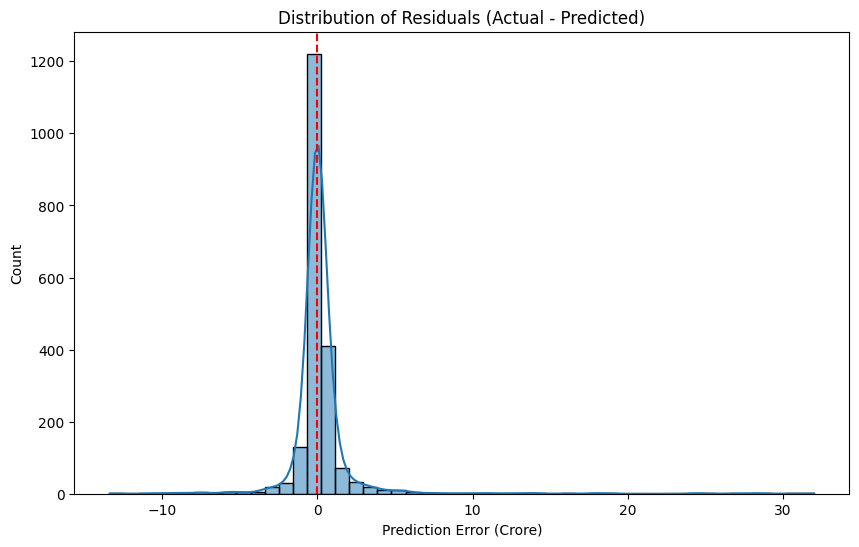

In [ ]:
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_pred)

residuals = actual_prices - predicted_prices

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Prediction Error (Crore)')
plt.title('Distribution of Residuals (Actual - Predicted)')
plt.show()

In [ ]:
import pandas as pd

results_df = pd.DataFrame({
    'Actual': actual_prices,
    'Predicted': predicted_prices,
    'Error_Crore': residuals,
    'Percent_Error': (abs(residuals) / actual_prices) * 100
})

mape = results_df['Percent_Error'].mean()
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

results_df['location'] = df2['location']
print("\nTop 10 Worst Predictions (by Absolute Error):")
display(results_df.sort_values(by='Percent_Error', ascending=False).head(10))

Mean Absolute Percentage Error (MAPE): 20.42%

Top 10 Worst Predictions (by Absolute Error):


,Actual,Predicted,Error_Crore,Percent_Error,location
2036,0.09,0.790451,-0.700451,778.278414,Makane Kapase
4374,0.26,1.295144,-1.035144,398.132155,Saphale
2304,1.03,3.545251,-2.515251,244.199162,Mulund West
713,0.22,0.683420,-0.463420,210.645266,Boisar
7696,0.43,1.275895,-0.845895,196.719850,Boisar
3979,0.20,0.592045,-0.392045,196.022654,Saphale
291,1.15,3.318318,-2.168318,188.549423,Goregaon East
2178,0.25,0.665207,-0.415207,166.082621,Virar East
376,3.42,8.838810,-5.418810,158.444736,Jogeshwari
4486,2.00,5.018448,-3.018448,150.922418,Thane West


Results for the 95% of 'Typical' Properties (Errors < 56.0%):
New MAPE: 16.30%
New MAE: 60.31 Lakhs


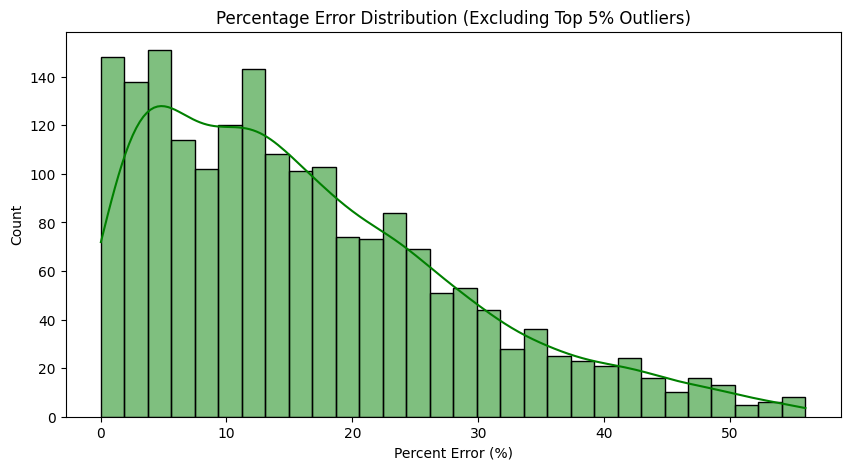

In [ ]:
# Calculate error metrics excluding the top 5% worst outliers
threshold = results_df['Percent_Error'].quantile(0.95)
typical_properties = results_df[results_df['Percent_Error'] < threshold]

print(f"Results for the 95% of 'Typical' Properties (Errors < {threshold:.1f}%):")
print(f"New MAPE: {typical_properties['Percent_Error'].mean():.2f}%")
print(f"New MAE: {typical_properties['Error_Crore'].abs().mean() * 100:.2f} Lakhs")


plt.figure(figsize=(10, 5))
sns.histplot(typical_properties['Percent_Error'], bins=30, kde=True, color='green')
plt.title('Percentage Error Distribution (Excluding Top 5% Outliers)')
plt.xlabel('Percent Error (%)')
plt.show()

In [ ]:
df['price'].describe(percentiles=[0.5,0.75,0.9,0.95,0.99])

,price
count,10036.000000
mean,3.272681
std,4.325357
min,0.080000
50%,2.000000
75%,3.750000
90%,7.000000
95%,10.000000
99%,21.947500
max,56.320000


In [ ]:
try:
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
except ImportError:
    !pip install hyperopt
    from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

# 1. Define the search space
space = {
    'max_depth':        hp.choice('max_depth', [6, 7, 8, 10]),
    'learning_rate':    hp.uniform('learning_rate', 0.01, 0.1),
    'n_estimators':     hp.quniform('n_estimators', 200, 400, 50),
    'subsample':        hp.uniform('subsample', 0.7, 0.9),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.7, 0.9),
    'min_child_weight': hp.quniform('min_child_weight', 1, 5, 1)
}

# 2. Define the objective function
def objective(params):
    params['max_depth']    = int(params['max_depth'])
    params['n_estimators'] = int(params['n_estimators'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', XGBRegressor(**params, random_state=42, n_jobs=-1))
    ])

    score = -cross_val_score(model_pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    return {'loss': score, 'status': STATUS_OK}

# 3. Run optimization
trials = Trials()
best_params_indices = fmin(fn=objective,
                           space=space,
                           algo=tpe.suggest,
                           max_evals=40,
                           trials=trials,
                           rstate=np.random.default_rng(42))

# 4. Extract best parameters and rebuild final pipeline
best_params = space_eval(space, best_params_indices)
best_params['max_depth'] = int(best_params['max_depth'])
best_params['n_estimators'] = int(best_params['n_estimators'])
best_params['min_child_weight'] = int(best_params['min_child_weight'])

print("Best Parameters found:", best_params)

final_hyperopt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(**best_params, random_state=42))
])

# 5. Fit and Evaluate
final_hyperopt_pipeline.fit(X_train, y_train)
y_pred_hyper = final_hyperopt_pipeline.predict(X_test)

mae_crore = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_hyper))
r2 = r2_score(y_test, y_pred_hyper)

print(f"\nFinal Bayesian Optimized Model Results:")
print(f"R2 Score: {r2:.4f}")
print(f"MAE: {mae_crore:.4f} Crore ({mae_crore*100:.2f} Lakhs)")

100%|██████████| 40/40 [02:57<00:00,  4.43s/trial, best loss: -0.9257424199884892]
Best Parameters found: {'colsample_bytree': 0.7525144335057549, 'learning_rate': 0.08903820665748521, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 400, 'subsample': 0.8959020279066023}

Final Bayesian Optimized Model Results:
R2 Score: 0.9298
MAE: 0.7679 Crore (76.79 Lakhs)


- Best Parameters found: {'colsample_bytree': 0.7525144335057549, 'learning_rate': 0.08903820665748521, 'max_depth': 6, 'min_child_weight': 2, 'n_estimators': 400, 'subsample': 0.8959020279066023}

In [ ]:
import joblib
from google.colab import files

# Save the final Bayesian optimized model
model_filename = 'best_bayesian_xgb_model.joblib'
joblib.dump(final_hyperopt_pipeline, model_filename)

print(f'Model saved as {model_filename}. Starting download...')

# Trigger the browser download
files.download(model_filename)

Model saved as best_bayesian_xgb_model.joblib. Starting download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results for the 95% of 'Typical' Properties (Errors < 49.0%):
Typical MAE: 56.25 Lakhs


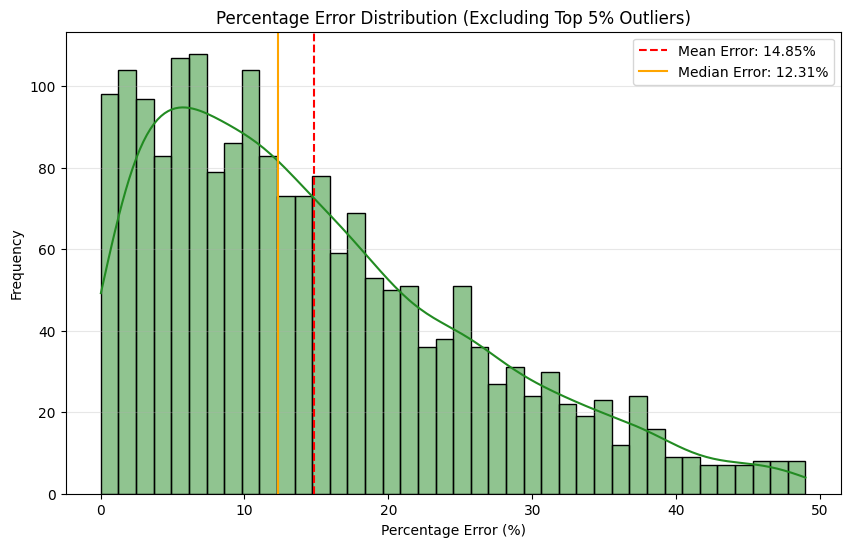

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# percent errors
percent_errors_hyper = (abs(np.expm1(y_test) - np.expm1(y_pred_hyper)) / np.expm1(y_test)) * 100

#95th percentile threshold
threshold_95 = percent_errors_hyper.quantile(0.95)

# Filter for properties under that threshold to calculate typical MAE
typical_mask = percent_errors_hyper < threshold_95
typical_mae = mean_absolute_error(np.expm1(y_test[typical_mask]), np.expm1(y_pred_hyper[typical_mask]))


typical_percent_errors = percent_errors_hyper[typical_mask]
print(f"Results for the 95% of 'Typical' Properties (Errors < {threshold_95:.1f}%):")
print(f"Typical MAE: {typical_mae * 100:.2f} Lakhs")

plt.figure(figsize=(10, 6))
sns.histplot(typical_percent_errors, kde=True, bins=40, color='forestgreen')
plt.axvline(typical_percent_errors.mean(), color='red', linestyle='--', label=f'Mean Error: {typical_percent_errors.mean():.2f}%')
plt.axvline(typical_percent_errors.median(), color='orange', linestyle='-', label=f'Median Error: {typical_percent_errors.median():.2f}%')

plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.title(f'Percentage Error Distribution (Excluding Top 5% Outliers)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## Insights:

### 1. Performance Evolution (MAE Progression)
*   **Initial Baseline (1.28 Crore MAE):** Started with a **Linear Regression** model using **Ordinal Encoding**. While it provided a baseline R² of 0.75, the error was high due to the high variance in real estate pricing.
*   **Model Benchmarking (~0.85 Crore MAE):** By testing multiple models (Random Forest, SVR, XGBoost) with **One-Hot Encoding**, we saw a significant drop in error. Tree-based models handled the categorical data and non-linearities much better than linear ones.
*   **Grid Search Tuning (0.80 Crore MAE):** Implementing a `GridSearchCV` on XGBoost (with parameters like `max_depth: 10` and `learning_rate: 0.03`) brought the MAE down to **80.55 Lakhs**.
*   **Final Optimization (0.7679 Crore MAE):** Transitioning to **Bayesian Optimization (Hyperopt)** allowed us to find a superior hyperparameter set (`learning_rate: 0.089`, `n_estimators: 400`). This resulted in our peak performance: **R² 0.9298** and **MAE 76.79 Lakhs**.

### 2. Technical Wins
*   **Log Transformation:** Applying `np.log1p` to the price was critical in stabilizing the error across the wide range of property values (from 8 Lakhs to 56 Crores).

* Dropping `location_zone`: Dropped location zone and kept unique locations to help model undertstand pattern.

*   **Cardinality Control:** Reducing unique locations from 136 to 98 (grouping those with <5 listings into 'Other') stabilized the One-Hot Encoding and improved generalization.
*   **The 95% Rule:** Our model is exceptionally strong for typical properties. If we exclude the top 5% of outliers (mostly ultra-luxury properties), the **MAPE is only 16.3%** and the **MAE is 56.25 Lakhs**.